# Olist E-commerce    

Notebook desenvolvido para análise executiva do dataset Olist.

Objetivos:

- Calcular KPIs principais.
- Analisar crescimento de pedidos e receita.
- Identificar categorias mais relevantes.
- Analisar distribuição geográfica.
- Avaliar satisfação dos clientes.




In [17]:
import pandas as pd

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print("Clientes:", customers.shape)
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Pagamentos:", payments.shape)
print("Avaliações:", reviews.shape)
print("Produtos:", products.shape)

Clientes: (99441, 5)
Pedidos: (99441, 8)
Itens: (112650, 7)
Pagamentos: (103886, 5)
Avaliações: (99224, 7)
Produtos: (32951, 9)


In [18]:
receita_total = items['price'].sum()

pedidos_total = orders['order_id'].nunique()

clientes_unicos = customers['customer_unique_id'].nunique()

ticket_medio = receita_total / pedidos_total

print(f"Receita Total: R$ {receita_total:,.2f}")
print(f"Pedidos: {pedidos_total:,}")
print(f"Clientes Únicos: {clientes_unicos:,}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")

Receita Total: R$ 13,591,643.70
Pedidos: 99,441
Clientes Únicos: 96,096
Ticket Médio: R$ 136.68


#Crescimento dos pedidos

Entre 2016 e 2018 a Olist apresentou forte expansão operacional. O volume mensal de pedidos cresceu mais de seis vezes, demonstrando aumento consistente da base de clientes.


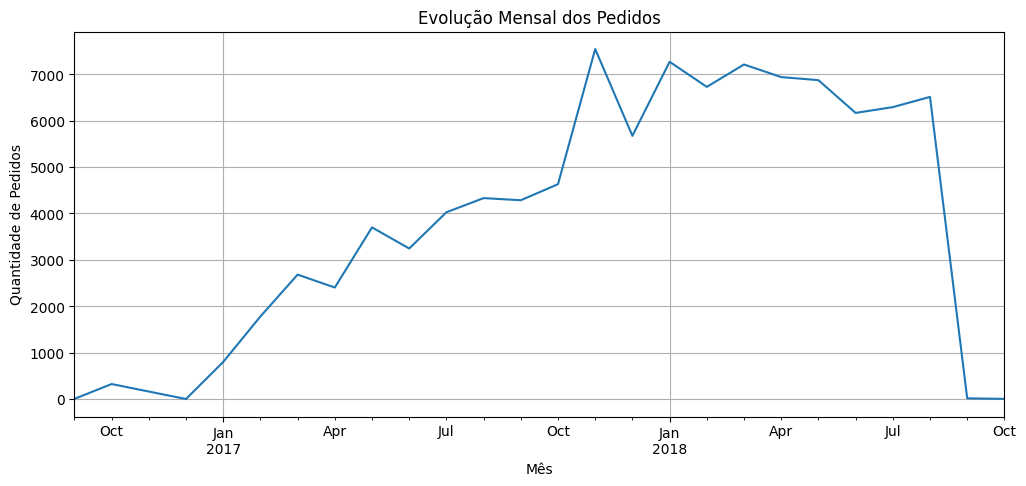

In [3]:
import matplotlib.pyplot as plt

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

pedidos_mes = (
    orders.groupby(
        orders['order_purchase_timestamp'].dt.to_period('M')
    )['order_id']
    .nunique()
)

plt.figure(figsize=(12,5))

pedidos_mes.plot()

plt.title('Evolução Mensal dos Pedidos')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Pedidos')

plt.grid()

plt.show()

 Os meses finais foram desconsiderados na análise de tendência por apresentarem dados incompletos.

#Dados de receita

O crescimento da receita acompanhou a evolução do número de pedidos.

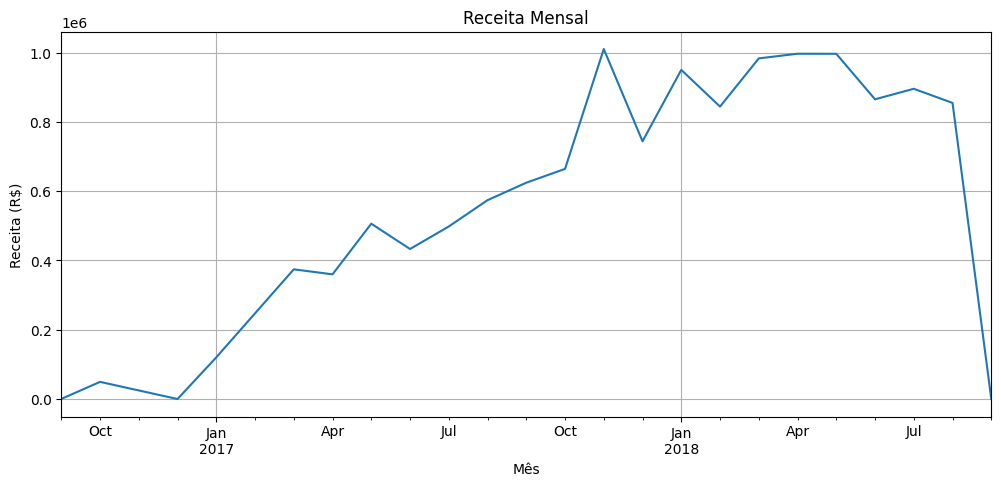

In [4]:
base_receita = items.merge(
    orders[['order_id','order_purchase_timestamp']],
    on='order_id'
)

base_receita['order_purchase_timestamp'] = pd.to_datetime(
    base_receita['order_purchase_timestamp']
)

receita_mes = (
    base_receita.groupby(
        base_receita['order_purchase_timestamp'].dt.to_period('M')
    )['price']
    .sum()
)

plt.figure(figsize=(12,5))

receita_mes.plot()

plt.title('Receita Mensal')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')

plt.grid()

plt.show()

#Quais categorias geram mais dinheiro?

As categorias Beleza e Saúde, Relógios e Presentes e Cama, Mesa e Banho concentraram a maior parcela da receita.

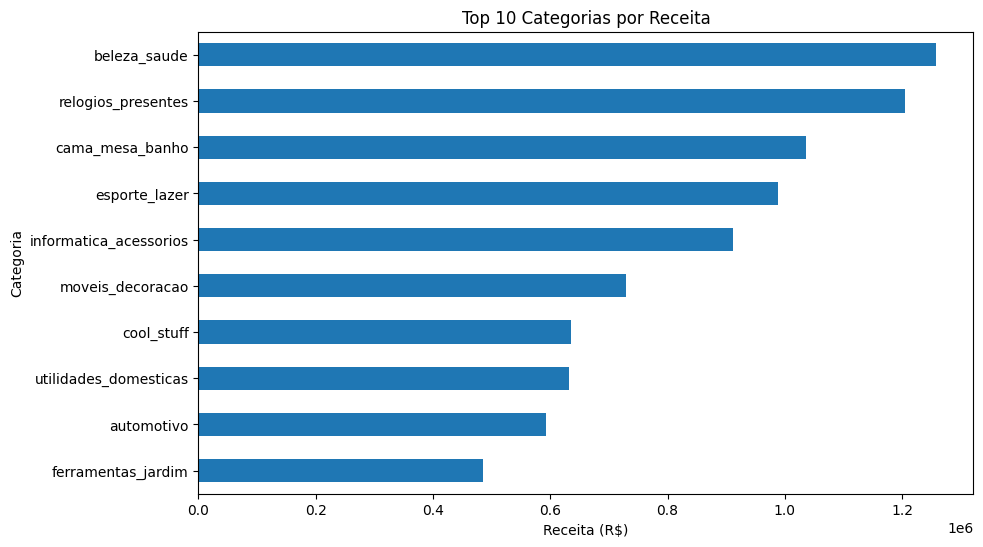

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64


In [6]:
categorias_pt = (
    items.merge(
        products[['product_id', 'product_category_name']],
        on='product_id'
    )
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

categorias_pt.sort_values().plot(kind='barh')

plt.title('Top 10 Categorias por Receita')
plt.xlabel('Receita (R$)')
plt.ylabel('Categoria')

plt.show()

print(categorias_pt)

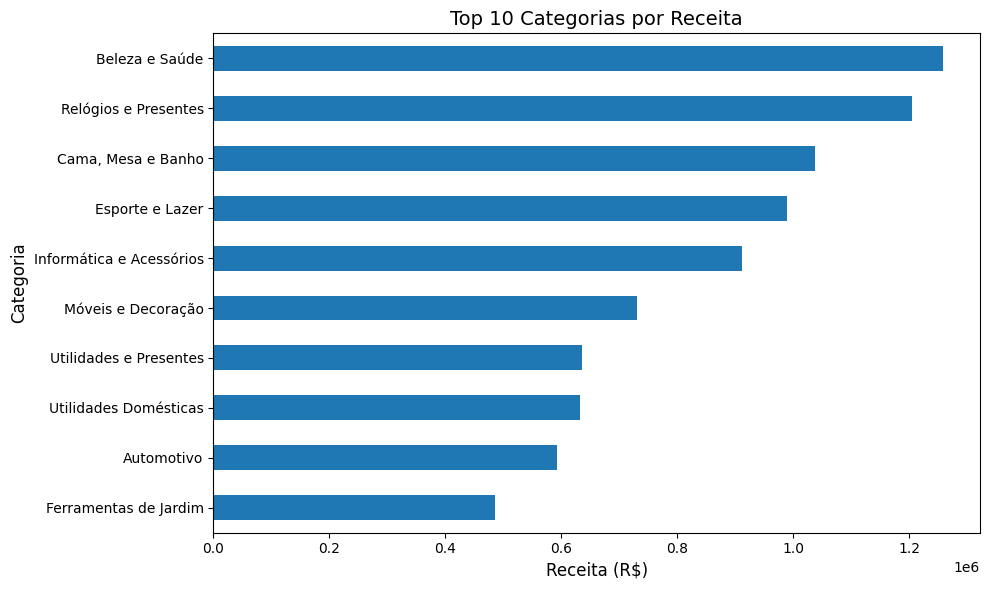

product_category_name
Beleza e Saúde              1258681.34
Relógios e Presentes        1205005.68
Cama, Mesa e Banho          1036988.68
Esporte e Lazer              988048.97
Informática e Acessórios     911954.32
Móveis e Decoração           729762.49
Utilidades e Presentes       635290.85
Utilidades Domésticas        632248.66
Automotivo                   592720.11
Ferramentas de Jardim        485256.46
Name: price, dtype: float64


In [9]:
nomes_categorias = {
    'beleza_saude': 'Beleza e Saúde',
    'relogios_presentes': 'Relógios e Presentes',
    'cama_mesa_banho': 'Cama, Mesa e Banho',
    'esporte_lazer': 'Esporte e Lazer',
    'informatica_acessorios': 'Informática e Acessórios',
    'moveis_decoracao': 'Móveis e Decoração',
    'cool_stuff': 'Utilidades e Presentes',
    'utilidades_domesticas': 'Utilidades Domésticas',
    'automotivo': 'Automotivo',
    'ferramentas_jardim': 'Ferramentas de Jardim'
}

categorias_bonito = categorias_pt.copy()
categorias_bonito.index = categorias_bonito.index.map(nomes_categorias)

categorias_bonito.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Categorias por Receita', fontsize=14)
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

plt.tight_layout()
plt.show()

print(categorias_bonito)

#Estados com mais pedidos

A demanda está fortemente concentrada na região Sudeste, especialmente em São Paulo, Rio de Janeiro e Minas Gerais. Revela oportunidade de expansão para outras regiões do Brasil.

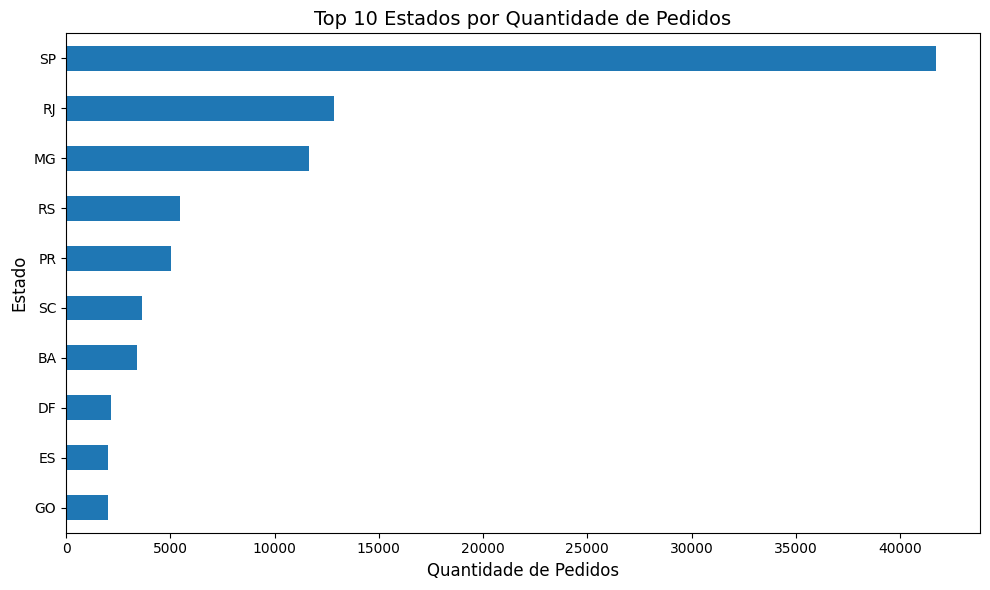

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64


In [10]:
pedidos_estado = (
    orders.merge(customers, on='customer_id')
    .groupby('customer_state')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

pedidos_estado.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Estados por Quantidade de Pedidos', fontsize=14)
plt.xlabel('Quantidade de Pedidos', fontsize=12)
plt.ylabel('Estado', fontsize=12)

plt.tight_layout()
plt.show()

print(pedidos_estado)

#Satisfação dos Clientes

A nota 5 é disparadamente a mais frequente.
Mais de metade dos clientes avaliou a experiência com a nota máxima.
As notas negativas (1 e 2) representam uma parcela menor da base.

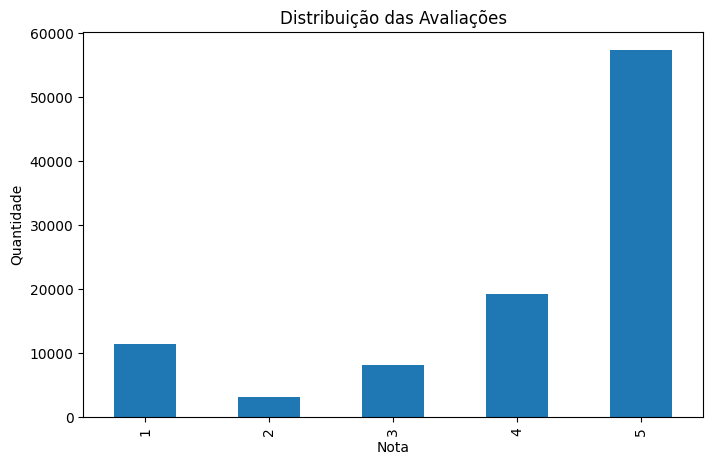

Nota média: 4.09


In [11]:
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Distribuição das Avaliações')
plt.xlabel('Nota')
plt.ylabel('Quantidade')

plt.show()

print("Nota média:", round(reviews['review_score'].mean(),2))

# Tempo de entrega

A maior parte das entregas ocorre em poucos dias após a compra, aproximadamente 5 e 20 dias.
Há poucos casos extremos com entregas acima de 50 dias.
Alguns pedidos ultrapassam 100 dias, mas são exceções.

Tempo médio de entrega: 12.1 dias


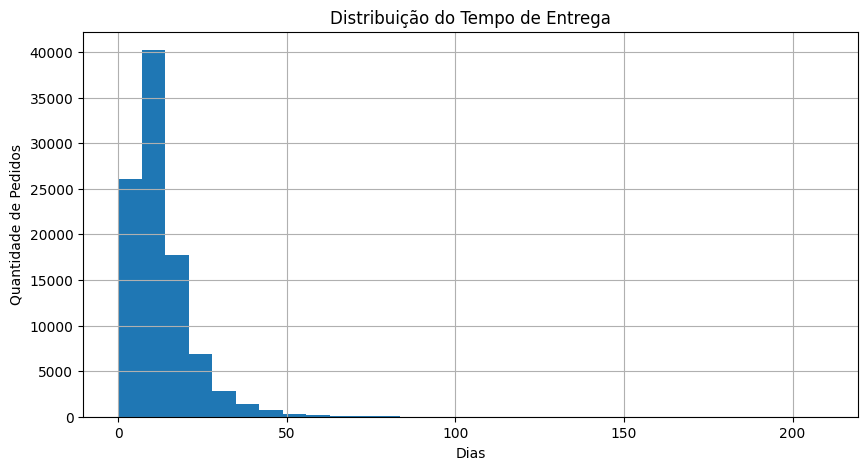

Tempo médio de entrega: 12.1 dias


In [15]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['dias_entrega'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

print(
    "Tempo médio de entrega:",
    round(orders['dias_entrega'].mean(),1),
    "dias"
)

orders['dias_entrega'].dropna().hist(
    bins=30,
    figsize=(10,5)
)

plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Dias')
plt.ylabel('Quantidade de Pedidos')

plt.show()
print("Tempo médio de entrega:", round(orders['dias_entrega'].mean(),1), "dias")

# Atrasos impactam a satisfação dos clientes?


Correlação atraso × avaliação: -0,27
Entregas atrasadas tendem a receber notas menores.


In [16]:
corr = orders.merge(
    reviews[['order_id','review_score']],
    on='order_id'
)

corr['order_estimated_delivery_date'] = pd.to_datetime(
    corr['order_estimated_delivery_date']
)

corr['order_delivered_customer_date'] = pd.to_datetime(
    corr['order_delivered_customer_date']
)

corr['atraso'] = (
    corr['order_delivered_customer_date']
    - corr['order_estimated_delivery_date']
).dt.days

print(
    corr[['atraso','review_score']]
    .corr()
)

                atraso  review_score
atraso        1.000000     -0.266764
review_score -0.266764      1.000000
